In [1]:
import math
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
#             plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, \
#             plot_all_features_in_2d_array, plot_latent_evolution_grid, read_yaml_params
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
# from torch import nn
# from torch.utils.data import DataLoader, TensorDataset
from torch_cluster import radius_graph

# from pathlib import Path
from typing import Optional
import seaborn as sns

# import cProfile
import gudhi
from gudhi import CubicalComplex

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
"main persistence code"

def generate_torus_point_cloud(n_points: int = 2000, R_major: float = 1.0, r_minor: float = 0.3,
                                          noise: float = 0.01, rand_seed: Optional[int] = None,
                                          device = device, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    """Generate a 2D torus-like (ring) point cloud on GPU using PyTorch.
    n_points = #points to generate
    rand_seed = random seed for reproducibility
    R_major/r_minor are the major/minor radii of the torus. Noise is added to r_minor"""

    if rand_seed is not None:
        torch.manual_seed(rand_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(rand_seed)

    theta  = torch.rand(n_points, device=device, dtype=dtype) * (2 * torch.pi)
    radial = R_major + r_minor * torch.randn(n_points, device=device, dtype=dtype)
    x      = radial * torch.cos(theta)
    y      = radial * torch.sin(theta)
    pts    = torch.stack([x, y], dim=1)
    pts    = pts + noise * torch.randn_like(pts)
    return pts

# to remove, edge_index is more efficient
def adjacency_from_distance_matrix(D: torch.Tensor, epsilon: float) -> torch.Tensor:
    """Given distance matrix D and threshold epsilon, find which node pairs are connected
    Output: binary (bool) adjacency matrix from distance matrix. No self-edges"""
    A = (D < epsilon) & (D > 0.0) # keep distances < epsilon, and remove self-edges (D=0)
    A = torch.triu(A, diagonal=1) # take upper triangle + remove diagonal
    A = A | A.T                   # applies upper triangle to lower part to make symmetric (without diagonal)
    return A

def count_edges(A: torch.Tensor) -> int:
    """Count undirected edges from upper (or lower) triangle"""
    return int(torch.triu(A, diagonal=1).sum().item())

def count_triangles_from_adjacency(A: torch.Tensor) -> int:
    """Count undirected triangles using spectral triangle counting.
    uses matrix trace identity: # triangles = trace(A^3)/6
    - each triangle appears 6 times"""
    Af = A.float()
    A3 = Af @ Af @ Af # compute A^3 (counts length-3 walks between nodes)
    return int(torch.trace(A3).item() / 6) # Trace gives total closed 3-walks; divide by 6 to correct overcounting

class UnionFind:
    """Union-find / disjoint set."""
    def __init__(self, n: int):
        self.parent = torch.arange(n, device=device)
        self.rank = torch.zeros(n, dtype=torch.int32, device=device)

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return int(x)

    def union(self, x: int, y: int):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return

        if self.rank[rx] < self.rank[ry]:
            self.parent[rx] = ry
        elif self.rank[rx] > self.rank[ry]:
            self.parent[ry] = rx
        else:
            self.parent[ry] = rx
            self.rank[rx] += 1

    def num_components(self) -> int:
        # roots = torch.unique(self.parent)
        roots = set(self.find(int(i)) for i in range(len(self.parent)))
        return len(roots)

class BettiComputer:
    def __init__(self, n_triangles, n_edges, n_vertices, device=device):
        self.n_triangles = n_triangles
        self.n_edges     = n_edges
        self.n_vertices  = n_vertices
        self.device      = device

    def compute_betti_0(self, adj: torch.Tensor, tolerance: float = 1e-5) -> int:
        """Connected components via Laplacian spectrum. Betti-0 via graph Laplacian.. B0 = vertices - rank."""
        A       = adj.float()
        degree  = torch.diag(A.sum(dim=1))
        L       = degree - A
        eigvals = torch.linalg.eigvalsh(L)
        return int((eigvals < tolerance).sum().item())

    def compute_betti_0_edge_index(self, edge_index: torch.Tensor, n_vertices: int) -> int:
        """Connected components via union-find."""
        uf       = UnionFind(n_vertices)
        src, dst = edge_index
        for i in range(src.numel()):
            uf.union(int(src[i]), int(dst[i]))
        self.B0 = uf.num_components()
        return self.B0

    def compute_betti_1(self, V: int, E: int, B0: int) -> int:
        """Betti B1 = edges + connected components - vertices
        connected components C = B0, which are the # of unique clusters of points"""
        return max(E + B0 - V, 0)


In [ ]:
"computations"
n_points     = 100
point_cloud  = generate_torus_point_cloud(n_points, R_major=1.0, r_minor=0.10, noise=0.005, rand_seed=4, device=device)

start_time = time.time()

D        = torch.cdist(point_cloud, point_cloud)
max_dist = D.max().item()
D        = D / max_dist # normalize to [0,1], better numerical stability

# ~~~~~~~~~~~~~~~~~~~~~
src, dst = torch.triu_indices(n_points, n_points, offset=1, device=device)
weights  = D[src, dst]
perm     = torch.argsort(weights)
src      = src[perm]
dst      = dst[perm]
weights  = weights[perm]
uf = UnionFind(n_points)

B0_arr = []
B1_arr = []

E = 0
for i in range(len(weights)):
    u = int(src[i])
    v = int(dst[i])

    uf.union(u, v)
    if uf.find(u) != uf.find(v):
        print(f"merge at eps={weights[i].item():.3f}")
    E += 1
    B0 = uf.num_components()
    B1 = E - n_points + B0

    if i % 500 == 0:
        print(
            f"step={i}/{len(weights)} | "
            f"eps={weights[i].item():.4f} | "
            f"E={E} | B0={B0} | B1={B1}")
    B0_arr.append(B0)
    B1_arr.append(B1)

# ~~~~~~~~~~~~~~~~~~~~~
# B0_arr, B1_arr = [], []
# betti_obj = BettiComputer(n_triangles=0, n_edges=0, n_vertices=n_points, device=device)

# counter= 0
# eps    = 0
# step   = 0.05

# while eps <= max_dist:
#     adj         = adjacency_from_distance_matrix(D, eps)
#     n_edges     = count_edges(adj)
#     n_triangles = count_triangles_from_adjacency(adj)
    
#     edge_index = radius_graph(point_cloud, r=eps, loop=False)
#     # B0 = betti_obj.compute_betti_0(adj, tolerance=1e-5)
#     B0 = betti_obj.compute_betti_0_edge_index(edge_index, n_vertices=n_points)
#     E  = edge_index.shape[1]
#     B1 = betti_obj.compute_betti_1(V=n_points, E=E, B0=B0)
#     B0_arr.append(B0)
#     B1_arr.append(B1)

#     density = E / (n_points * (n_points - 1) // 2)

#     if (counter + 1) % 5 == 0:
#         print(f"eps={eps:.2f}/{max_dist:.2f} | "
#             f"edges={n_edges}/{n_points*(n_points-1)//2} | "
#             f"triangles={n_triangles}/{math.comb(n_points, 3)} | "
#             f"Betti: B0={B0}, B1={B1} | "
#             f"Density: {density:.4f}")
#     eps += step
#     counter += 1
# # ~~~~~~~~~~~~~~~~~~~~~

end_time = time.time()
print(f"⚠️ Operations completed in {end_time - start_time:.4f} seconds")

plt.figure()
plt.plot(np.arange(len(B0_arr)) * step, np.log(B0_arr), label='log(B0)')
plt.plot(np.arange(len(B1_arr)) * step, np.log(B1_arr), label='log(B1)')
plt.legend()
plt.show()

# ===============
plt.scatter(point_cloud[:, 0].cpu(), point_cloud[:, 1].cpu(), s=2)
plt.gca().set_aspect('equal')
plt.show()
plt.figure()
sns.heatmap(D.cpu(), cmap='viridis')
plt.title("Distance matrix")


In [ ]:
M       = np.array([[0, 1, 0, 1, 1, 0],
                    [1, 0, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 0],
                    [1, 0, 0, 0, 0, 1],
                    [1, 1, 0, 0, 0, 1],
                    [0, 0, 0, 1, 1, 0]])
M_bool  = M.astype(bool)
M2      = M@M # number of shared friends
M2_bool = (M2 > 0)

triangles = M2_bool & M_bool  # shared friend AND direct edge
np.fill_diagonal(triangles, False)  # ignore diagonal

print("M2:\n", M2)
print("Triangles matrix:\n", triangles)

In [2]:
"gudhi implementation"
matplotlib.rcParams['text.usetex'] = False

def make_yvals(x):
    # return 0.005*x**2 + torch.sin(x) #-0.01*x**3+0.25*x**2 -8*torch.sin(x) #1.8*x**3 + 3*x**2 + 8*x - 0.5*x**4 +0.02*x**5 #+torch.sin(x) #.1*x + torch.sin(x) + torch.sin(0.1 * x**2)
    return 3*torch.sin(0.4*x) + 0.1*x

start_point, end_point = 1, 10_000_000
num_timesteps = end_point #100
x_vals = torch.linspace(start_point, end_point, num_timesteps)
y_vals = make_yvals(x_vals)

num_timesteps_new = 80
x_new  = torch.linspace(end_point+1, end_point+ num_timesteps_new, num_timesteps_new)
y_new  = make_yvals(x_new)

cc = CubicalComplex(dimensions=y_vals.shape, top_dimensional_cells=y_vals.numpy().flatten())
cc.compute_persistence()
pairs = cc.persistence()  # (dimension, (birth, death))

# gudhi.plot_persistence_diagram(cc.persistence())
# gudhi.plot_persistence_barcode(cc.persistence())

# plt.figure()
# plt.plot(x_vals.numpy(), y_vals.numpy())
# plt.show()


In [ ]:
"tomato"
from gudhi.clustering.tomato import Tomato
from sklearn.datasets import make_blobs

# data
points, _ = make_blobs(n_samples=300, centers=8, random_state=42)

# fit
t = Tomato(metric='euclidean', k=10)
t.fit(points)

# 1. plot persistence diagram manually
# t.diagram_ contains (birth, death) pairs
dgm = t.diagram_
plt.scatter(dgm[:, 0], dgm[:, 1])
plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlabel('birth')
plt.ylabel('death')
plt.title('persistence diagram — look for gap')
plt.show()

# 2. set clusters after inspecting diagram
t.n_clusters_ = 3
labels = t.labels_

# 3. plot clustering result
plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='tab10')
plt.title('ToMATo result')
plt.show()

KeyboardInterrupt: 

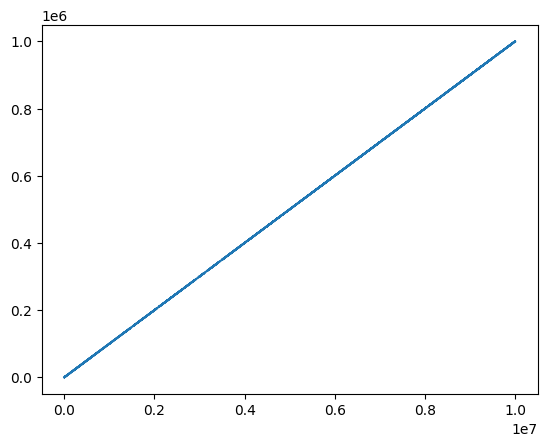

In [ ]:
"old sublevel"

# NOTE: we currently treat min-boundary as boundary, need to treat as min
# NOTE: when there are many equal g-min, gudhi makes just 1 go to inf, the other one dies at g-max
# (can be seen as a 'bug')
# TODO: when we increment the timeseries, the boundary min/gmin need to be removed (since the bonudary is gone)

MIN, MAX, GMIN, GMAX = 1, -1, 2, -2 # int encodings for keypoints

class Sublevel1D:
    """Implementation for 1D timeseries sublevel β₀ persistence. We keep track of keypoints (min/max/gmin/gmax) and their indices, and then compute persistence pairs via a pairing algorithm
    We also use vectors (no arrays/dicts) to make it parallelizable"""
    def __init__(self, x: torch.Tensor = None):
        """x = 1D timeseries"""
        self.x      = x # timeseries signal
        self.device = x.device

        # keypoints
        self.keypoint_idx   = None
        self.keypoint_types = None
        # persistence arrays (one entry per minimum pt)
        self.persistence_idx    = None # indices of each MINIMUM
        self.persistence_births = None # = y-val
        self.persistence_deaths = None # = y=val
        # active 
        self.active_min_idx = None  # minima idx, consumed during pairing
        self.active_min_y   = None  # minima y-val, consumed during pairing
        self.active_max_idx = None  # maxima idx, consumed during pairing
        self.active_max_y   = None  # maxima y-val, consumed during pairing
        # globals
        self.gmax_idx  = None
        self.gmax_yval = None
        self.gmin_idx  = None
        self.gmin_yval = None

    def find_extrema_in_timeseries(self) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns (indices, types) of minima and maxima, sorted by index.
        Types: MIN=1, MAX=-1, GMIN=2, GMAX=-2.
        - Having many gmin/gmax values is correctly labeled
        - Interior gmin/gmax are upgraded from min/max via isin check
        - We assess whether boundary points are min/max based on their neighbor (if < neighbor they its a min, elts its a max);
        - boundary maxima are discarded (they mess up persistence)
        - If gmax only appears at boundaries, we ignore it and promote next highest interior max to GMAX
        NOTE: keeping only keypoints indirectly de-duplicates the dataset, solving the 'plateaus' problem"""

        # Vectorized comparison with neighbors
        is_min = (self.x[1:-1] < self.x[:-2]) & (self.x[1:-1] < self.x[2:])
        is_max = (self.x[1:-1] > self.x[:-2]) & (self.x[1:-1] > self.x[2:])
        
        # Adjust indices because we sliced off the boundaries
        min_idx  = torch.nonzero(is_min).flatten() + 1
        max_idx  = torch.nonzero(is_max).flatten() + 1

        gmin_val = self.x.min()
        gmax_val = self.x.max()
        gmin_idx = torch.nonzero(self.x == gmin_val).flatten()
        gmax_idx = torch.nonzero(self.x == gmax_val).flatten()

        # upgrade min/max to gmin/gmax before concat
        min_types = torch.where(torch.isin(min_idx, gmin_idx),
                                torch.tensor(GMIN, device=self.device),
                                torch.tensor(MIN,  device=self.device))
        max_types = torch.where(torch.isin(max_idx, gmax_idx),
                                torch.tensor(GMAX, device=self.device),
                                torch.tensor(MAX,  device=self.device))

        # boundaries: keep only if min/gmin, discard if max/gmax
        boundary_indices, boundary_types_list = [], []
        for idx, neighbor in [(0, 1), (len(self.x) - 1, len(self.x) - 2)]:
            val = self.x[idx]
            if val == gmax_val:
                pass  # discard
            elif val < self.x[neighbor]:
                boundary_indices.append(idx)
                boundary_types_list.append(GMIN if val == gmin_val else MIN)
            # else: boundary is a non-global max → discard

        # promote next interior max to GMAX if boundary was gmax and no interior gmax exists
        left_was_gmax  = self.x[0]   == gmax_val
        right_was_gmax = self.x[-1]  == gmax_val
        boundary_stole_gmax = (left_was_gmax or right_was_gmax) and not torch.isin(max_idx, gmax_idx).any()
        if boundary_stole_gmax:
            interior_max_val = self.x[1:-1].max()
            promoted_idx     = torch.nonzero(self.x[1:-1] == interior_max_val).flatten() + 1
            max_types        = torch.where(torch.isin(max_idx, promoted_idx),
                                           torch.tensor(GMAX, device=self.device), max_types)

        if boundary_indices:
            b_idx     = torch.tensor(boundary_indices,    device=self.device)
            b_types   = torch.tensor(boundary_types_list, device=self.device)
            all_idx   = torch.cat([min_idx, max_idx, b_idx])
            all_types = torch.cat([min_types, max_types, b_types])
        else:
            all_idx   = torch.cat([min_idx, max_idx])
            all_types = torch.cat([min_types, max_types])

        sort_key  = all_idx * 10 - all_types.abs()  # GMIN/GMAX before MIN/MAX at same index. *10 > max type abs val (2), so index dominates
        order     = torch.argsort(sort_key)
        all_idx   = all_idx[order]
        all_types = all_types[order]

        mask = torch.cat([torch.tensor([True], device=self.device),
                        all_idx[1:] != all_idx[:-1]])

        self.keypoint_idx, self.keypoint_types = all_idx[mask], all_types[mask]
        return self.keypoint_idx, self.keypoint_types

    def init_persistence_tensors(self):
        """Function that initializes the persistence process. Creates persistence arrays for [GLOBAL]-MINIMA ONLY (maxima dont die). birth/death values are usually y-vals (can be idx)
        - persistence_idx:   original series index of each minimum
        - persistence_births: y-val at birth (known immediately)
        - persistence_deaths: y-val at death (inf until pairing fills it; stays inf for gmin)
        NOTE: we set all min points' persistence to ∞ (only gmin is correctly set to die at ∞), which need to be updated later"""

        # minima (they are born and die)
        min_mask                = (self.keypoint_types == MIN) | (self.keypoint_types == GMIN)
        min_idx                 = self.keypoint_idx[min_mask] #which indices are [g]-minima
        self.persistence_idx    = min_idx # consists of minima only
        self.persistence_births = self.x[min_idx] # birth y-val is known immediately for minima
        self.persistence_deaths = torch.full((min_mask.sum(),), float('inf'), device=self.device) # pre-fill
        self.active_min_idx     = self.persistence_idx # minima start as active (not yet paired)
        self.active_min_y       = self.persistence_births

        # maxima; they dont have persistence since they dont die, but kill minima
        max_mask                = (self.keypoint_types == MAX)
        max_idx                 = self.keypoint_idx[max_mask] #which indices are [g]-maxima
        self.max_yvals          = self.x[max_idx]
        self.active_max_idx     = max_idx.clone()
        self.active_max_y       = self.max_yvals.clone()

        # globals
        self.gmax_idx           = self.keypoint_idx[self.keypoint_types == GMAX]
        self.gmin_idx           = self.keypoint_idx[self.keypoint_types == GMIN]
        self.gmax_yval          = self.x[self.gmax_idx]
        self.gmin_yval          = self.x[self.gmin_idx]

    def compute_persistence_for_gmin_and_opposite_gmin(self):
        """1D sublevel β₀ persistence algo for 1d timeseries
        the # components = # min or max indices
        Step 1: find the lowest min on the opposite side of gmax from gmin → dies at gmax.
        Step 2: remove it and gmin from active arrays (gmin dies at inf, already set)."""

        # find active mins on OPPOSITE side of gmin (wrt to gmax)
        if self.gmin_idx < self.gmax_idx:
            opposite_mask = self.active_min_idx > self.gmax_idx  # gmin on left → look right
        else:
            opposite_mask = self.active_min_idx < self.gmax_idx  # gmin on right → look left

        opposite_idx   = self.active_min_idx[opposite_mask]  # series positions of opposite-side mins
        opposite_yvals = self.active_min_y[opposite_mask]    # their y-vals

        # lowest opposite-side min = other side's gmin → dies at gmax
        local_argmin      = torch.argmin(opposite_yvals)    # local position within opposite arrays
        opposite_gmin_idx = opposite_idx[local_argmin]      # its position in original series

        # assign death
        death_loc = (self.persistence_idx == opposite_gmin_idx).nonzero().flatten()[0]
        self.persistence_deaths[death_loc] = self.gmax_yval

        # remove both gmin and other_gmin from active arrays
        remove_mask         = ~torch.isin(self.active_min_idx,
                                          torch.tensor([opposite_gmin_idx, self.gmin_idx], device=self.device))
        self.active_min_idx = self.active_min_idx[remove_mask]
        self.active_min_y   = self.active_min_y[remove_mask]

    def _get_neighbors_for_1_max(self):
        argmin         = torch.argmin(self.active_max_y)  # local position within active arrays
        max_series_idx = self.active_max_idx[argmin]      # position in original series
        max_yval       = self.active_max_y[argmin]        # its yval

        # find adjacent mins: one to the left, one to the right of this max
        left_mask  = self.active_min_idx < max_series_idx
        right_mask = self.active_min_idx > max_series_idx
        left_idx   = self.active_min_idx[left_mask]
        right_idx  = self.active_min_idx[right_mask]

        # nearest neighbor on each side: gmax acts as natural barrier, so cross-side mins are never nearest
        left_neighbor  = left_idx[-1] if len(left_idx)  > 0 else None
        right_neighbor = right_idx[0] if len(right_idx) > 0 else None

        # pick higher min (lower persistence = dies first)
        if left_neighbor is None:
            victim_idx = right_neighbor
        elif right_neighbor is None:
            victim_idx = left_neighbor
        else:
            left_y     = self.x[left_neighbor]
            right_y    = self.x[right_neighbor]
            victim_idx = left_neighbor if left_y > right_y else right_neighbor

        # assign death
        death_loc = (self.persistence_idx == victim_idx).nonzero().flatten()[0]
        self.persistence_deaths[death_loc] = max_yval

        # consume victim min AND this max from active arrays
        min_remove = (self.active_min_idx != victim_idx)
        max_remove = (self.active_max_idx != max_series_idx)
        # min_remove = ~torch.isin(self.active_min_idx, torch.tensor([victim_idx], device=self.device))
        # max_remove = ~torch.isin(self.active_max_idx, torch.tensor([max_series_idx], device=self.device))
        self.active_min_idx = self.active_min_idx[min_remove]
        self.active_min_y   = self.active_min_y[min_remove]
        self.active_max_idx = self.active_max_idx[max_remove]
        self.active_max_y   = self.active_max_y[max_remove]


    def compute_persistence_for_other_minima(self):
        """Pair remaining mins with their lowest adjacent max (elder rule).
        Each iteration: start with lowest active max point, find 2 adjacent mins on either side (wrt gmax),
        kill the min point closest to it (in terms of y value), then remove both points from active arrays"""

        while len(self.active_max_idx) > 0: # keep going until we have no more active maxima
            # lowest active max is the next kill event
            argmin         = torch.argmin(self.active_max_y)  # local position within active arrays
            max_series_idx = self.active_max_idx[argmin]      # position in original series
            max_yval       = self.active_max_y[argmin]        # its yval

            # find adjacent mins: one to the left, one to the right of this max
            left_mask  = self.active_min_idx < max_series_idx
            right_mask = self.active_min_idx > max_series_idx
            left_idx   = self.active_min_idx[left_mask]
            right_idx  = self.active_min_idx[right_mask]

            # nearest neighbor on each side: gmax acts as natural barrier, so cross-side mins are never nearest
            left_neighbor  = left_idx[-1] if len(left_idx)  > 0 else None
            right_neighbor = right_idx[0] if len(right_idx) > 0 else None

            # pick higher min (lower persistence = dies first)
            if left_neighbor is None:
                victim_idx = right_neighbor
            elif right_neighbor is None:
                victim_idx = left_neighbor
            else:
                left_y     = self.x[left_neighbor]
                right_y    = self.x[right_neighbor]
                victim_idx = left_neighbor if left_y > right_y else right_neighbor

            # assign death
            death_loc = (self.persistence_idx == victim_idx).nonzero().flatten()[0]
            self.persistence_deaths[death_loc] = max_yval

            # consume victim min AND this max from active arrays
            min_remove = (self.active_min_idx != victim_idx)
            max_remove = (self.active_max_idx != max_series_idx)
            # min_remove = ~torch.isin(self.active_min_idx, torch.tensor([victim_idx], device=self.device))
            # max_remove = ~torch.isin(self.active_max_idx, torch.tensor([max_series_idx], device=self.device))
            self.active_min_idx = self.active_min_idx[min_remove]
            self.active_min_y   = self.active_min_y[min_remove]
            self.active_max_idx = self.active_max_idx[max_remove]
            self.active_max_y   = self.active_max_y[max_remove]


class IncrementalSublevel(Sublevel1D):
    """This class inherits from the sublevel class, and is used to handle incremented timeseries chunks"""
    def __init__(self, x_new, x: torch.Tensor = None):
        super().__init__(x)
        self.x_new = x_new

        self.inc_keypoint_idx   = None
        self.inc_keypoint_types = None
        # persistence arrays (one entry per minimum pt)
        self.inc_persistence_idx    = None # indices of each MINIMUM
        self.inc_persistence_births = None # = y-val
        self.inc_persistence_deaths = None # = y=val
        # active 
        self.inc_active_min_idx = None  # minima idx, consumed during pairing
        self.inc_active_min_y   = None  # minima y-val, consumed during pairing
        self.inc_active_max_idx = None  # maxima idx, consumed during pairing
        self.inc_active_max_y   = None  # maxima y-val, consumed during pairing
        # globals
        self.inc_gmax_idx  = None
        self.inc_gmax_yval = None
        self.inc_gmin_idx  = None
        self.inc_gmin_yval = None
        # i want to have attributes for the incremented timeseries!!

    def add_timeseries(self):
        """function to add new chunk to our timeseries"""
        self.x = torch.cat([self.x, self.x_new], dim=0)

    def update_persistence_with_new_series(self):
        """ok"""

    def handle_no_gmin_or_gmax():
        """Case for no new g-min or g-max."""
        self.inc_keypoint_idx, self.inc_keypoint_types = self.find_extrema_in_timeseries()

        self.inc_gmax_idx  = self.inc_keypoint_idx[self.inc_keypoint_types == GMAX]
        self.inc_gmin_idx  = self.inc_keypoint_idx[self.inc_keypoint_types == GMIN]
        self.inc_gmax_yval = self.x[self.inc_gmax_idx]
        self.inc_gmin_yval = self.x[self.inc_gmin_idx]

        if (self.inc_gmax_yval > self.gmax_yval):
            if (self.inc_gmin_yval < self.gmin_yval):
                print("new gmax and new gmin")
            else:
                print("new gmax but no new gmin")
        elif (self.inc_gmax_yval > self.gmax_yval):
            if (self.inc_gmin_yval < self.gmin_yval):
                print("new gmin but no new gmax")
            else:
                print("no new gmax or gmin")

        # apply persistence
        self.init_persistence_tensors()
        self.compute_persistence_for_gmin_and_opposite_gmin()
        self.compute_persistence_for_other_minima()

        # then concat persistence of old + new series
        # so here i want to concat 2 arrays, but how to get the new persistence as array? should the functions in the above lines output something or no (since theyre in self?)?

        # 0) if increment has no gmin or gmax
            # then we compute the increment's persistence and append it to the current one

        # 1) if increment has new gmin
            # 1) if new gmin is on opposite side of old gmin
                # new gmin > inf, old gmin > gmax
            # 2) if new gmin is on same side as old gmin
                # old gmin > nearby mamx [previouslt old gmin > inf]. Careful with this step
                # new gmin > inf
            # 3) if gmin is on boundary, treat it as normal point and proceed. find its position wrt gmax and work accordingly

        # 2) if increment has new gmax
            # 1) if new gmax is on opposite side of old gmin (wrt old gmax)
                # boundary shifted to new gmax
                # old gmin dies at inf [same as before]
                # new opposite lowest min (NOT gmin), dies at new gmax [new g-maximum will create new minima,
                    # unless it is at boundary, in which case it is not a proper g-max and we take the next highest max as g-max]
            # 2) if new gmax is on same side as old gmin (wrt old gmax)
                # boundary shifted to new gmax, so new points become on opposite side as gmin
                # old gmin > inf [same as before]
                # on newly created side of gmax (=right side), lowest min dies at new gmax
            # 3) if new gmax is on boundary
                # boundary max dont kill, so ignore it, treat the 2nd highest max as gmax

        # 3) if increment has new gmin AND new gmax
            # 1) if new gmin is on SAME side of old gmin
                # oldest lowest min op opposite side of old gmin killed by old gmax
                # new gmax kills lowest min on opposite side of new gmin [previously this old gmin > inf]
            # 2) if new gmin is on OPPOSITE side as old gmin
                # old gmin dies at gmax [prev this old gmin > inf]
                # new gmin > inf

plt.plot(x_vals.numpy(), y_vals.numpy())

sublevel_obj = Sublevel1D(x=y_vals)
keypoint_idx, keypoint_types = sublevel_obj.find_extrema_in_timeseries()
sublevel_obj.init_persistence_tensors()
sublevel_obj.compute_persistence_for_gmin_and_opposite_gmin()
sublevel_obj.compute_persistence_for_other_minima()

# print("keypoint idx:", keypoint_idx)
# print("keypoint types:", keypoint_types)
print("persistence idx:", sublevel_obj.persistence_idx)
print("persistence birth:", sublevel_obj.persistence_births)
print("persistence death:", sublevel_obj.persistence_deaths)
print(f"{sublevel_obj.gmax_idx=} {sublevel_obj.gmax_yval=}")
print("active max idx:", sublevel_obj.active_max_idx)
print("active max y:", sublevel_obj.active_max_y)

# increment_obj = IncrementalSublevel(x_new=y_new)
# increment_obj.add_timeseries()
# increment_obj.find_extrema_in_timeseries()


In [ ]:
plt.scatter(range(len(sublevel_obj.persistence_births)), sublevel_obj.persistence_births)
plt.scatter(range(len(sublevel_obj.persistence_deaths)), sublevel_obj.persistence_deaths)

In [ ]:
from numba import njit

MIN, MAX, GMIN, GMAX = 1, -1, 2, -2 # int encodings for keypoints

class PersistenceLake1D:
    """An optimized Disjoint-Set (Union-Find) structure customized for 
    1D Topological Data Analysis (Sublevel Set Filtration / Elder Rule)."""
    def __init__(self, keypoint_series_idx: torch.Tensor, device: torch.device):
        num_keypoints = len(keypoint_series_idx)
        self.basin_membership_ids = torch.arange(num_keypoints, device=device) 
        self.keypoint_idx_array   = keypoint_series_idx.clone().to(device) 

    def find_root_sequence_rank(self, keypoint_sequence_rank: int) -> int:
        """Finds the root component sequence rank using iterative path compression."""
        cursor_rank = keypoint_sequence_rank
        while cursor_rank != self.basin_membership_ids[cursor_rank]:
            self.basin_membership_ids[cursor_rank] = self.basin_membership_ids[self.basin_membership_ids[cursor_rank]]
            cursor_rank = self.basin_membership_ids[cursor_rank]
        return int(cursor_rank)

    def merge_basins_via_elder_rule(self, left_sequence_rank: int, right_sequence_rank: int, timeseries_values: torch.Tensor):
        """Merges two adjacent components using the TDA Elder Rule.
        Returns the (victim_birth_series_idx) of the feature that dies."""
        left_root_rank  = self.find_root_sequence_rank(left_sequence_rank)
        right_root_rank = self.find_root_sequence_rank(right_sequence_rank)

        if left_root_rank == right_root_rank:
            return None

        left_birth_height  = timeseries_values[self.keypoint_idx_array[left_root_rank]]
        right_birth_height = timeseries_values[self.keypoint_idx_array[right_root_rank]]

        if left_birth_height > right_birth_height:
            victim_birth_series_idx = self.keypoint_idx_array[left_root_rank]
            self.basin_membership_ids[left_root_rank] = right_root_rank
            return victim_birth_series_idx
        else:
            victim_birth_series_idx = self.keypoint_idx_array[right_root_rank]
            self.basin_membership_ids[right_root_rank] = left_root_rank
            return victim_birth_series_idx

class OnlineSublevelPersistence:
    """Maintains a persistent, incrementally updated Lake Registry across data streams."""
    def __init__(self, initial_x: torch.Tensor, initial_keypoint_idx: torch.Tensor, initial_keypoint_types: torch.Tensor):
        self.device = initial_x.device
        self.history_values = initial_x.clone()
        
        # Instantiate and populate historical state in the registry
        self.lake_registry = PersistenceLake1D(initial_keypoint_idx, self.device)
        self.num_keypoints = len(initial_keypoint_idx)
        
        # Persist a clean, running array of keypoint types matching the registry sizes
        self.keypoint_types = initial_keypoint_types.clone().to(self.device)
        
        # Track which keypoint positions are currently active (submerged)
        self.submerged_components = torch.zeros(self.num_keypoints, dtype=torch.bool, device=self.device)
        
        # Run a batch sweep over the initial baseline data to catch up state
        self._sweep_increment(range(self.num_keypoints))

    def _sweep_increment(self, sequence_ranks_to_process: list):
        """Sweeps a specific subset of sorted sequence ranks and emits persistence pairs."""
        new_pairs = []
        
        # Sort incoming sequence ranks by their actual time-series height values
        heights = self.history_values[self.lake_registry.keypoint_idx_array[sequence_ranks_to_process]]
        sorted_indices = torch.argsort(heights)
        
        for idx in sorted_indices.tolist():
            active_sequence_rank = sequence_ranks_to_process[idx]
            # Clean, direct lookup from our tracking tensor
            keypoint_type        = self.keypoint_types[active_sequence_rank].item()
            active_series_idx    = self.lake_registry.keypoint_idx_array[active_sequence_rank]

            if keypoint_type in (MIN, GMIN):
                self.submerged_components[active_sequence_rank] = True

            elif keypoint_type in (MAX, GMAX):
                left_rank  = active_sequence_rank - 1
                right_rank = active_sequence_rank + 1

                has_left  = (left_rank >= 0) and self.submerged_components[self.lake_registry.find_root_sequence_rank(left_rank)]
                has_right = (right_rank < self.num_keypoints) and self.submerged_components[self.lake_registry.find_root_sequence_rank(right_rank)]

                if has_left and has_right:
                    victim_birth_idx = self.lake_registry.merge_basins_via_elder_rule(left_rank, right_rank, self.history_values)
                    if victim_birth_idx is not None:
                        new_pairs.append((int(victim_birth_idx.item()), int(active_series_idx.item())))
                        
                elif has_left:
                    self.lake_registry.basin_membership_ids[active_sequence_rank] = self.lake_registry.find_root_sequence_rank(left_rank)
                    self.submerged_components[active_sequence_rank] = True
                elif has_right:
                    self.lake_registry.basin_membership_ids[active_sequence_rank] = self.lake_registry.find_root_sequence_rank(right_rank)
                    self.submerged_components[active_sequence_rank] = True
                    
        return new_pairs

    def handle_boundary_point(self, new_x_chunk: torch.Tensor):
        """Evaluates and stitches the 4-point stitching window between history and stream."""
        old_len = len(self.history_values)
        if old_len < 2 or len(new_x_chunk) < 2:
            return None, None
            
        pts = [
            self.history_values[-2].item(),
            self.history_values[-1].item(),
            new_x_chunk[0].item(),
            new_x_chunk[1].item()]
        
        old_last_type = None
        if pts[1] < pts[0] and pts[1] < pts[2]:
            old_last_type = MIN
        elif pts[1] > pts[0] and pts[1] > pts[2]:
            old_last_type = MAX
            
        new_first_type = None
        if pts[2] < pts[1] and pts[2] < pts[3]:
            new_first_type = MIN
        elif pts[2] > pts[1] and pts[2] > pts[3]:
            new_first_type = MAX
            
        return old_last_type, new_first_type

    def append_stream_data(self, new_x_chunk: torch.Tensor, stream_keypoint_idx: torch.Tensor, stream_keypoint_types: torch.Tensor):
        """Appends streaming data chunk, updates tracking structures, and emits new pairs."""
        old_history_len = len(self.history_values)
        
        # 1. Update full historical values tracking array immediately
        self.history_values = torch.cat([self.history_values, new_x_chunk])
        
        # Shift incoming stream index markers to align with global time tracker
        adjusted_stream_idx = stream_keypoint_idx + old_history_len
        
        # 2. Update persistent global type tensor
        self.keypoint_types = torch.cat([self.keypoint_types, stream_keypoint_types.to(self.device)])
        
        new_num_keypoints = self.num_keypoints + len(adjusted_stream_idx)
        
        # Resize registry tensors dynamically
        extended_membership = torch.arange(new_num_keypoints, device=self.device)
        extended_membership[:self.num_keypoints] = self.lake_registry.basin_membership_ids
        self.lake_registry.basin_membership_ids = extended_membership
        
        self.lake_registry.keypoint_idx_array = torch.cat([self.lake_registry.keypoint_idx_array, adjusted_stream_idx])
        
        # Expand submerged state buffer
        extended_submerged = torch.zeros(new_num_keypoints, dtype=torch.bool, device=self.device)
        extended_submerged[:self.num_keypoints] = self.submerged_components
        self.submerged_components = extended_submerged
        
        # Determine sequence positions requiring processing
        start_rank = self.num_keypoints
        self.num_keypoints = new_num_keypoints
        ranks_to_process = list(range(start_rank, self.num_keypoints))
        
        # 3. Sweep exclusively over the incremental additions
        new_pairs = self._sweep_increment(ranks_to_process)
        
        return new_pairs


def compute_1d_sublevel_persistence(timeseries_values: torch.Tensor, keypoint_series_idx: torch.Tensor, keypoint_types: torch.Tensor):
    device        = timeseries_values.device
    num_keypoints = len(keypoint_series_idx)

    # Calculate heights and sort them entirely on the current device
    keypoint_heights    = timeseries_values[keypoint_series_idx]
    sweep_line_schedule = torch.argsort(keypoint_heights)

    lake_registry        = PersistenceLake1D(keypoint_series_idx, device)
    submerged_components = torch.zeros(num_keypoints, dtype=torch.bool, device=device)
    
    birth_death_pairs_list = []

    # SPEEDUP FIX 1: Convert type matching to integer operations on the GPU/CPU directly
    # This lets us skip slow Python string/tuple checks inside the loop
    is_min_mask = (keypoint_types == MIN) | (keypoint_types == GMIN)
    is_max_mask = (keypoint_types == MAX) | (keypoint_types == GMAX)

    # SPEEDUP FIX 2: Convert to a list of integers once so the python loop iterates at bare-metal speeds
    schedule_list = sweep_line_schedule.tolist()

    for active_sequence_rank in schedule_list:
        # Quick tensor lookups on the target device
        active_series_idx = keypoint_series_idx[active_sequence_rank]

        if is_min_mask[active_sequence_rank]:  
            submerged_components[active_sequence_rank] = True

        elif is_max_mask[active_sequence_rank]:  
            left_rank  = active_sequence_rank - 1
            right_rank = active_sequence_rank + 1

            # Clean inline evaluations
            has_left  = (left_rank >= 0) and submerged_components[lake_registry.find_root_sequence_rank(left_rank)]
            has_right = (right_rank < num_keypoints) and submerged_components[lake_registry.find_root_sequence_rank(right_rank)]

            if has_left and has_right:
                victim_birth_series_idx = lake_registry.merge_basins_via_elder_rule(
                    left_rank, right_rank, timeseries_values)
                if victim_birth_series_idx is not None:
                    # Append natively as integers directly
                    birth_death_pairs_list.append((int(victim_birth_series_idx), int(active_series_idx))) 

            elif has_left:
                lake_registry.basin_membership_ids[active_sequence_rank] = lake_registry.find_root_sequence_rank(left_rank)
                submerged_components[active_sequence_rank] = True
            
            elif has_right:
                lake_registry.basin_membership_ids[active_sequence_rank] = lake_registry.find_root_sequence_rank(right_rank)
                submerged_components[active_sequence_rank] = True
                
    return birth_death_pairs_list

# 1. Extract keypoints for your baseline history (y_vals)
sublevel_baseline = Sublevel1D(x=y_vals)
base_keypoint_idx, base_keypoint_types = sublevel_baseline.find_extrema_in_timeseries()

batch_pairs = compute_1d_sublevel_persistence(y_vals, base_keypoint_idx, base_keypoint_types)

# print(f"Total pairs found in full batch: {len(batch_pairs)}")
# for b, d in batch_pairs:
#     print(f"Batch Pair: ({b}, {d})")

# # 2. INITIALIZE the online persistence engine with your baseline history
# online_tda = OnlineSublevelPersistence(y_vals, base_keypoint_idx, base_keypoint_types)

# # 3. Extract keypoints for your incoming streaming chunk (y_new)
# sublevel_stream = Sublevel1D(x=y_new)
# stream_keypoint_idx, stream_keypoint_types = sublevel_stream.find_extrema_in_timeseries()

# # 4. Append the streaming chunk to process incremental changes
# # This outputs ONLY the new pairs closed by the arrival of y_new
# birth_death_pairs_list = online_tda.append_stream_data(
#     new_x_chunk=y_new, 
#     stream_keypoint_idx=stream_keypoint_idx, 
#     stream_keypoint_types=stream_keypoint_types)

# # 5. PRINT RESULTS (Using your exact style)
# # Note: online_tda.history_values is now automatically the unified (y_vals + y_new) tensor

# print("--- Persistence Pairs: (birth idx, death idx) ---")
# for birth_time_idx, death_time_idx in birth_death_pairs_list:
#     print(f"({birth_time_idx}, {death_time_idx})")

# print("\n--- y values: (birth, death; lifetime) ---")
# for birth_idx, death_idx in birth_death_pairs_list:
#     birth_val = online_tda.history_values[birth_idx].item()
#     death_val = online_tda.history_values[death_idx].item()
#     print(f"({birth_val:2.2f}, {death_val:2.2f}; {death_val - birth_val:2.2f})")
